# Generate images and videos with MuJoCo

This notebook demonstrates how to render still images and videos from a MuJoCo simulation using RobotBlockSet utilities.

The main steps are:

- load previously generated robot motion data
- initialize a MuJoCo scene and robot model
- interpolate the trajectory for smooth rendering
- render several static camera views
- create videos from those views
- combine multiple views into one video
- create a moving camera view that tracks the tool

This notebook focuses on rendering and visualization, not on motion planning itself. For planning collision-free trajectories see tutorial **tutorial_generation_collision-free_trajectories**.


In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from time import sleep, time
from copy import copy
import mediapy as media
from pathlib import Path

import mujoco
from robotblockset.mujoco.tools_pymujoco import check_path_for_collisions, make_free_camera, check_collisions, get_joints_under_body
from robotblockset.tools import get_rbs_path
from robotblockset.transformations import map_pose, rot_x, rot_y, rot_z, rp2t, frame2world
from robotblockset.mujoco.tools_pymujoco import get_robot_joints_data, get_geoms_of_body, get_body_descendants
from robotblockset.mujoco.tools_pymujoco import min_body_env_distance, min_robot_env_distance
from robotblockset.trajectories import interpPath, interpCartesianPath

from robotblockset.mujoco.scene_pymujoco_sim import mujoco_scene
from robotblockset.mujoco.robots_pymujoco_sim import ur10e

np.set_printoptions(precision=3, suppress=True, linewidth=100)

The notebook imports MuJoCo, RobotBlockSet simulation helpers, trajectory interpolation tools, and media utilities used to display or save rendered outputs.


# Initialization

Define the MuJoCo model path and the image resolution used for rendering.


In [2]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/"
HEIGHT = 960
WIDTH  = 1280

Load trajectory data. This example uses motion data generated previously, for example with **tutorial_generation_collision-free_trajectories**.


In [ ]:
mat = scipy.io.loadmat("/tutorials/assets/inspection_path.mat")
q_start    = mat.get("q_start").flatten()
q_goal     = mat.get("q_goal").flatten()
waypts     = mat.get("waypts")
path       = mat.get("path")
T          = mat.get("T").flatten()
path_rq    = mat.get("path_rq")
path_rqd   = mat.get("path_rqd")
path_rqdd  = mat.get("path_rqdd")

In [ ]:
mat = scipy.io.loadmat("/tutorials/assets/inspection_results.mat")
tt   = mat.get("tt").flatten()
qt   = mat.get("qt")
qdt  = mat.get("qdt")
xt   = mat.get("xt")
vt   = mat.get("vt")
rxt  = mat.get("rxt")
rvt  = mat.get("rvt")
rqt  = mat.get("rqt")
rqdt = mat.get("rqdt")
mt   = mat.get("mt").flatten()

# Prepare scene

Create the MuJoCo scene, initialize the robot, and configure the environment so rendering can focus on the task-relevant objects.


### Load scene

Open MuJoCo simulator and load scene (**inspection_scene.xml**)

In [5]:
scene = mujoco_scene(MODEL_PATH + "inspection_scene.xml", show_viewer=False)

Define and initialize robot

In [6]:
rs = ur10e(scene=scene)
rs.Restart(keyframe=0)
rs.JMove(q_start)

[RBS_INFO] [17:33:08] [ur10e_PyMuJoCo]: Robot connected to MuJoCo


0

Close the gripper

In [7]:
rs.SendAuxCtrl([6], [160])
rs.JMove(q_start)

0

### Get all necessary robot data

The following cell collects the bodies and geoms associated with part of the environment so that selected objects can be hidden or emphasized in different rendered views.


In [8]:
bodies = get_body_descendants(scene.model, "camera2_stand", include_self=True)
geoms = get_geoms_of_body(scene.model, bodies)
for g in geoms:
    scene.model.geom(g).group = 5

### Interpolate data for image and video generation.

The recorded trajectory is resampled to a lower-rate sequence that is dense enough for smooth video rendering but cheaper to render than the full trajectory.


In [9]:
t_video = np.arange(0.0, tt[-1], 0.04)
q_video = interpPath(tt, qt, t_video)
rxtw = frame2world(rxt, rs.TBase)
x_robot = interpCartesianPath(tt, rxtw, t_video)
samples = [10, 15, 20, 30, 40, 50, 60]

### Prepare rendering utilities for images that show multiple robot configurations in one frame.

The idea is to render several semi-transparent "ghost" robot poses together with one highlighted pose to visualize the motion in a single still image.


In [10]:
model = scene.model
jnt, _ = get_joints_under_body(scene.model, "ur10e")
qaddr, _ = get_robot_joints_data(scene.model, jnt[:6])

# Visual options for the "ghost" robots.
vopt1 = mujoco.MjvOption()

vopt2 = mujoco.MjvOption()
vopt2.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True  # Transparent.
pert = mujoco.MjvPerturb()  # Empty MjvPerturb object
# We only want dynamic objects. Static objects (the floor)
# should not be re-drawn. The mjtCatBit flag lets us do that, though we could
# equivalently use mjtVisFlag.mjVIS_STATIC
catmask = mujoco.mjtCatBit.mjCAT_DYNAMIC

# Image and video generation

Each subsection below defines a camera view, renders a single preview image, and then generates a video from the interpolated trajectory.


### View 1

Render the first fixed camera view and highlight one panel of the scene.


""

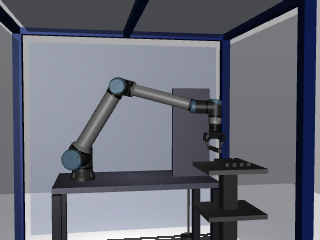

In [11]:
scene.model.geom("panel_right").group = 5
scene.model.geom("panel_left").group = 4
scene.model.geom("panel_front").group = 4
cam = make_free_camera(rs.scene.model, azimuth=-190, elevation=-2, distance=3.0, lookat=[0, 0.2, 1.2], fovy=35)
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
frame = scene.mj_capture_camera(camera=cam, scene_option=scene_option)
media.show_image(frame)

""

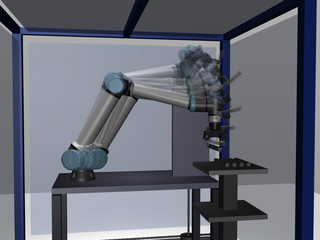

In [12]:
with mujoco.Renderer(model, height=HEIGHT, width=WIDTH) as renderer:
    rs.Restart(qpos=q_start, u=q_start, reset=False)
    data = copy(scene.data)
    renderer.update_scene(data, camera=cam, scene_option=scene_option)
    
    _data = copy(scene.data)
    qq = _data.qpos.copy()
    for isamp in samples:
        for i, adr in enumerate(qaddr):
            qq[adr] = q_video[isamp, i]
        _data.qpos[:] = qq
        mujoco.mj_forward(model, _data)
        mujoco.mjv_addGeoms(model, _data, vopt2, pert, catmask, renderer.scene)

    for i, adr in enumerate(qaddr):
        qq[adr] = q_video[70, i]
    _data.qpos[:] = qq
    mujoco.mj_forward(model, _data)
    mujoco.mjv_addGeoms(model, _data, vopt1, pert, catmask, renderer.scene)

    #   # Render and add the frame.
    pixels = renderer.render()

# Render video at half real-time.
media.show_image(pixels, width=320, height=240)
# media.write_image("inspection_right_side_view.png", pixels)

In [13]:
frames = []
for q in q_video:
    rs.Restart(qpos=q, u=q, reset=False)
    frame = scene.mj_capture_camera(camera=cam, height=HEIGHT, width=WIDTH, scene_option=scene_option)
    frames.append(frame)
media.show_video(frames, fps=25, width=320, height=240)
# media.write_video("inspection_right_side_view.mp4", frames, fps=25)

This browser does not support the video tag.


### View 2

Render a second fixed view from the front side of the scene.


""

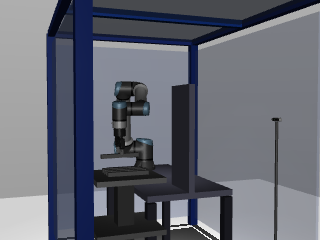

In [14]:
scene.model.geom("panel_right").group = 4
scene.model.geom("panel_left").group = 4
scene.model.geom("panel_front").group = 5
scene_option.geomgroup = [1, 1, 1, 0, 1, 0]
cam1 = make_free_camera(rs.scene.model, azimuth=-110, elevation=-2, distance=3.0, lookat=[0,0,1.2], fovy=35)
frame = scene.mj_capture_camera(camera=cam1, scene_option=scene_option)
media.show_image(frame)

""

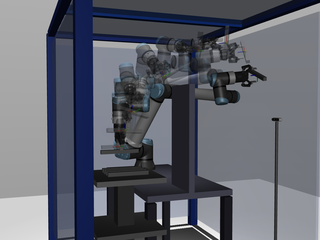

In [15]:
with mujoco.Renderer(model, height=HEIGHT, width=WIDTH) as renderer:
    rs.Restart(qpos=q_start, u=q_start, reset=False)
    data = copy(scene.data)
    renderer.update_scene(data, camera=cam1, scene_option=scene_option)
    
    _data = copy(scene.data)
    qq = _data.qpos.copy()
    for isamp in samples:
        for i, adr in enumerate(qaddr):
            qq[adr] = q_video[isamp, i]
        _data.qpos[:] = qq
        mujoco.mj_forward(model, _data)
        mujoco.mjv_addGeoms(model, _data, vopt2, pert, catmask, renderer.scene)

    for i, adr in enumerate(qaddr):
        qq[adr] = q_video[70, i]
    _data.qpos[:] = qq
    mujoco.mj_forward(model, _data)
    mujoco.mjv_addGeoms(model, _data, vopt1, pert, catmask, renderer.scene)

    #   # Render and add the frame.
    pixels = renderer.render()

# Render video at half real-time.
media.show_image(pixels, width=320, height=240)
# media.write_image("inspection_front_view.png", pixels)

### View 3

Render a third fixed view with a different free-camera configuration.


""

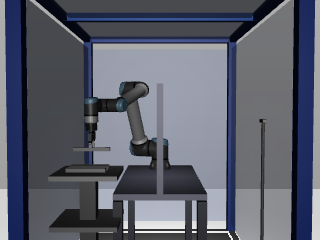

In [16]:
cam2 = make_free_camera(rs.scene.model, azimuth=-90, elevation=-2, distance=3.0, lookat=[0,0,1.2], fovy=35)
frame = scene.mj_capture_camera(camera=cam2, scene_option=scene_option)
media.show_image(frame)

""

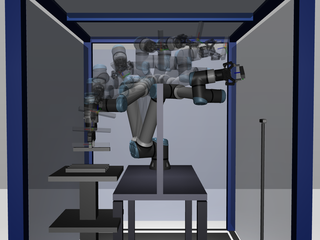

In [17]:
with mujoco.Renderer(model, height=HEIGHT, width=WIDTH) as renderer:
    rs.Restart(qpos=q_start, u=q_start, reset=False)
    data = copy(scene.data)
    renderer.update_scene(data, camera=cam2, scene_option=scene_option)
    
    _data = copy(scene.data)
    qq = _data.qpos.copy()
    for isamp in samples:
        for i, adr in enumerate(qaddr):
            qq[adr] = q_video[isamp, i]
        _data.qpos[:] = qq
        mujoco.mj_forward(model, _data)
        mujoco.mjv_addGeoms(model, _data, vopt2, pert, catmask, renderer.scene)

    for i, adr in enumerate(qaddr):
        qq[adr] = q_video[70, i]
    _data.qpos[:] = qq
    mujoco.mj_forward(model, _data)
    mujoco.mjv_addGeoms(model, _data, vopt1, pert, catmask, renderer.scene)

    #   # Render and add the frame.
    pixels = renderer.render()

# Render video at half real-time.
media.show_image(pixels, width=320, height=240)
# media.write_image("inspection_front_view1.png", pixels)

In [18]:
frames2 = []
for q in q_video:
    rs.Restart(qpos=q, u=q, reset=False)
    frame = scene.mj_capture_camera(camera=cam2, height=HEIGHT, width=WIDTH, scene_option=scene_option)
    frames2.append(frame)
media.show_video(frames2, fps=25, width=320, height=240)
# media.write_video("inspection_front_view.mp4", frames2, fps=25)

This browser does not support the video tag.


### View 4

Render a fourth fixed view from the opposite side of the scene.


""

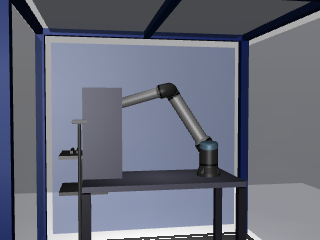

In [19]:
scene.model.geom("panel_right").group = 4
scene.model.geom("panel_left").group = 5
scene.model.geom("panel_front").group = 4
cam3 = make_free_camera(rs.scene.model, azimuth=-10, elevation=-2, distance=3.0, lookat=[0,0,1.2], fovy=35)
frame = scene.mj_capture_camera(camera=cam3, scene_option=scene_option)
media.show_image(frame)

""

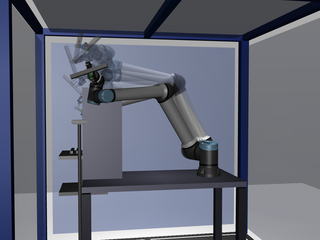

In [20]:
with mujoco.Renderer(model, height=HEIGHT, width=WIDTH) as renderer:
    rs.Restart(qpos=q_start, u=q_start, reset=False)
    data = copy(scene.data)
    renderer.update_scene(data, camera=cam3, scene_option=scene_option)
    
    _data = copy(scene.data)
    qq = _data.qpos.copy()
    for isamp in samples:
        for i, adr in enumerate(qaddr):
            qq[adr] = q_video[isamp, i]
        _data.qpos[:] = qq
        mujoco.mj_forward(model, _data)
        mujoco.mjv_addGeoms(model, _data, vopt2, pert, catmask, renderer.scene)

    for i, adr in enumerate(qaddr):
        qq[adr] = q_video[70, i]
    _data.qpos[:] = qq
    mujoco.mj_forward(model, _data)
    mujoco.mjv_addGeoms(model, _data, vopt1, pert, catmask, renderer.scene)

    #   # Render and add the frame.
    pixels = renderer.render()
    frames.append(pixels)

# Render video at half real-time.
media.show_image(pixels, width=320, height=240)
# media.write_image("inspection_left_side_view.png", pixels)

In [21]:
frames3 = []
for q in q_video:
    rs.Restart(qpos=q, u=q, reset=False)
    frame = scene.mj_capture_camera(camera=cam3, height=HEIGHT, width=WIDTH, scene_option=scene_option)
    frames3.append(frame)
media.show_video(frames3, fps=25, width=320, height=240)
# media.write_video("inspection_left_side_view.mp4", frames3, fps=25)

This browser does not support the video tag.


### Make a combined video

The videos from several viewpoints can be concatenated horizontally to produce a single multi-view video.


In [22]:
stacked_frames = [
    np.concatenate((f1, f2, f3), axis=1)
    for f1, f2, f3 in zip(frames, frames2, frames3)
]
media.show_video(stacked_frames, fps=25, width=320*3, height=240)
# media.write_video("inspection_all_views.mp4", stacked_frames, fps=25)

This browser does not support the video tag.


### Moving camera view tracking tool

The final example updates the camera look-at point along the trajectory so the rendered view follows the robot tool.


""

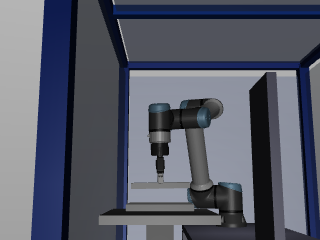

In [23]:
scene.model.geom("panel_right").group = 4
scene.model.geom("panel_left").group = 4
scene.model.geom("panel_front").group = 5
cam4 = make_free_camera(rs.scene.model, azimuth=-90, elevation=10, distance=1.2, lookat=[0.45,0.9,1.2], fovy=35)
frame = scene.mj_capture_camera(camera=cam4, scene_option=scene_option)
media.show_image(frame)

In [24]:
frames4 = []
for i, q in enumerate(q_video):
    rs.Restart(qpos=q, u=q, reset=False)
    cam4.lookat = x_robot[i, :3]
    frame = scene.mj_capture_camera(camera=cam4, height=HEIGHT, width=WIDTH, scene_option=scene_option)
    frames4.append(frame)
media.show_video(frames4, fps=25, width=320, height=240)
# media.write_video("inspection_track_view.mp4", frames4, fps=25)

This browser does not support the video tag.
